In [1]:
import os

# Clone the GitHub repository
!git clone https://github.com/castiel0312/kala-tel-.git

# Change into the cloned directory
# You might need to adjust this based on the repository's structure
repo_name = 'kala-tel-'
if os.path.exists(repo_name):
    os.chdir(repo_name)
    print(f"Changed directory to {os.getcwd()}")
else:
    print(f"Repository {repo_name} not found after cloning.")

Cloning into 'kala-tel-'...
remote: Enumerating objects: 6390, done.
remote: Counting objects: 100% (6390/6390), done.
remote: Compressing objects: 100% (5320/5320), done.
remote: Total 6390 (delta 963), reused 6387 (delta 960), pack-reused 0 (from 0)
Receiving objects: 100% (6390/6390), 33.61 MiB | 18.61 MiB/s, done.
Resolving deltas: 100% (963/963), done.
Changed directory to /content/kala-tel-


In [2]:
!ls


data  forge16b_inspect_output.txt  ml	      pyproject.toml  scripts  web
docs  Makefile			   notebooks  reports	      tests


In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [6]:
import pandas as pd

df = pd.read_csv("data/processed/drilling_timeseries.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(124497, 27)
['timestamp', 'wellbore_id', 'run_id', 'md', 'tvd', 'formation', 'rig_state', 'rop', 'wob', 'rpm', 'torque', 'hookload', 'drag', 'flow_in', 'flow_out', 'pump_rate', 'standpipe_pressure', 'ecd', 'mud_weight', 'pit_volume', 'gas_total', 'h2s', 'original_units', 'conversion_rule', 'conversion_version', 'source', 'data_origin']


,timestamp,wellbore_id,run_id,md,tvd,formation,rig_state,rop,wob,rpm,...,ecd,mud_weight,pit_volume,gas_total,h2s,original_units,conversion_rule,conversion_version,source,data_origin
0,2023-04-26T02:30:00,FORGE16B7832-01,NaN,35.9877,35.9877,NaN,ON_BOTTOM,25.4843,3.7810,26.9600,...,NaN,NaN,86.3826,NaN,NaN,ft;klbf;psi;gal/min;bbl;ppm;spm,ft->m;klbf->kN;psi->MPa;gal/min->L/min;bbl->m3...,1.1.0,pason 10 second data (1-min resample),PUBLIC_REAL
1,2023-04-26T02:31:00,FORGE16B7832-01,FORGE16B7832-01-RUN-1,36.1798,36.1798,NaN,ON_BOTTOM,11.6627,3.8553,26.9917,...,NaN,NaN,86.1870,NaN,NaN,ft;klbf;psi;gal/min;bbl;ppm;spm,ft->m;klbf->kN;psi->MPa;gal/min->L/min;bbl->m3...,1.1.0,pason 10 second data (1-min resample),PUBLIC_REAL
2,2023-04-26T02:32:00,FORGE16B7832-01,FORGE16B7832-01-RUN-1,36.4724,36.4724,NaN,ON_BOTTOM,17.3396,4.8930,27.6600,...,NaN,NaN,86.0519,NaN,NaN,ft;klbf;psi;gal/min;bbl;ppm;spm,ft->m;klbf->kN;psi->MPa;gal/min->L/min;bbl->m3...,1.1.0,pason 10 second data (1-min resample),PUBLIC_REAL
3,2023-04-26T02:33:00,FORGE16B7832-01,FORGE16B7832-01-RUN-1,36.8076,36.8076,NaN,ON_BOTTOM,20.9123,7.6363,28.0583,...,NaN,NaN,85.8070,NaN,NaN,ft;klbf;psi;gal/min;bbl;ppm;spm,ft->m;klbf->kN;psi->MPa;gal/min->L/min;bbl->m3...,1.1.0,pason 10 second data (1-min resample),PUBLIC_REAL
4,2023-04-26T02:34:00,FORGE16B7832-01,FORGE16B7832-01-RUN-1,37.1368,37.1368,NaN,ON_BOTTOM,21.9786,10.5276,28.5517,...,NaN,NaN,85.6210,NaN,NaN,ft;klbf;psi;gal/min;bbl;ppm;spm,ft->m;klbf->kN;psi->MPa;gal/min->L/min;bbl->m3...,1.1.0,pason 10 second data (1-min resample),PUBLIC_REAL


In [7]:
events = pd.read_csv("data/processed/events.csv")

print(events["event_type"].value_counts())

event_type
EQUIPMENT_FAILURE       26
STUCK_PIPE              10
CEMENT_FAILURE           4
WELLBORE_INSTABILITY     1
WASHOUT                  1
MUD_LOSS                 1
PACK_OFF                 1
Name: count, dtype: int64


In [3]:
!ls /content

sample_data


In [4]:
import os

folders = [
    "data/raw/forge_78b_32",
    "data/raw/forge_56_32",
    "data/raw/forge_58_32",
    "data/raw/volve",
    "data/raw/lost_circulation"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created")

Folders created


In [5]:
!git clone https://github.com/HaythamElmousalami/Drilling-Lost-circulation.git

Cloning into 'Drilling-Lost-circulation'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 1.45 MiB | 14.43 MiB/s, done.


In [6]:
!cp Drilling-Lost-circulation/CirculationDataV2.csv data/raw/lost_circulation/

In [7]:
!ls -lh data/raw/lost_circulation/

total 4.2M
-rw-r--r-- 1 root root 4.2M Sep 27 10:22 CirculationDataV2.csv


In [8]:
!pip install -q kaggle

In [9]:
!pip install -q kagglehub

In [10]:
import kagglehub

# Download the latest version
path = kagglehub.dataset_download(
    "imranulhaquenoor/volve-dataset-well-f-9-a"
)

print("Path to dataset files:", path)

100%|██████████| 38.5M/38.5M [00:00<00:00, 142MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/imranulhaquenoor/volve-dataset-well-f-9-a/versions/1


In [11]:
import os

print(os.listdir(path))

['Norway-NA-15_47_9-F-9 A time.csv', 'Norway-NA-15_47_9-F-9 A depth.csv']


In [12]:
import shutil
import os

for file in os.listdir(path):
    source = os.path.join(path, file)
    destination = os.path.join("data/raw/volve", file)

    if os.path.isfile(source):
        shutil.copy2(source, destination)

print("Volve dataset copied!")

Volve dataset copied!


In [13]:
!ls -lh data/raw/volve

total 414M
-rw-r--r-- 1 root root 5.4M Sep 27 10:25 'Norway-NA-15_47_9-F-9 A depth.csv'
-rw-r--r-- 1 root root 409M Sep 27 10:26 'Norway-NA-15_47_9-F-9 A time.csv'


In [14]:
!pip install -q datasets

After running the cell above, the repository will be cloned into your Colab environment. You can then navigate into the `kala-tel-` directory and work with its contents.

In [17]:
import os

os.makedirs("data/raw/forge_78b_32", exist_ok=True)

!wget -O "data/raw/forge_78b_32/pason_10sec.csv" \
"https://gdr.openei.org/files/1330/78B-32%2010%20sec%20data%2027200701.csv"

--2026-09-27 10:31:52--  https://gdr.openei.org/files/1330/78B-32%2010%20sec%20data%2027200701.csv
Resolving gdr.openei.org (gdr.openei.org)... 32.188.237.189, 52.32.183.69, 32.188.184.24
Connecting to gdr.openei.org (gdr.openei.org)|32.188.237.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 762053403 (727M) [application/octet-stream]
Saving to: ‘data/raw/forge_78b_32/pason_10sec.csv’

data/raw/forge_78b_ 100%[===================>] 726.75M  59.8MB/s    in 13s     

2026-09-27 10:32:05 (57.6 MB/s) - ‘data/raw/forge_78b_32/pason_10sec.csv’ saved [762053403/762053403]



### 4. Combine Compatible Labeled Datasets

Given that only `df_lc` currently contains explicit and reliably identified mud-loss labels, we will proceed with `df_lc` as our primary dataset for building the mud loss prediction model. The `df` and `df78` datasets lack clear mud loss indicators, and the 'events' dataset would require extensive, potentially unreliable, mapping to generate labels for them. Therefore, no further combination of datasets is performed for this specific task.

### 5. Create Useful Time/Rolling Drilling Features Without Data Leakage

### 8. Train XGBoost as the main model & 9. Handle class imbalance

In [25]:
import xgboost as xgb

# 8. Train XGBoost as the main model & 9. Handle class imbalance

# Calculate scale_pos_weight for handling class imbalance
# This assigns a weight to the positive class to balance the negative class count
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

print(f"\nPositive samples in training data: {pos_count}")
print(f"Negative samples in training data: {neg_count}")
print(f"Scale Positive Weight for XGBoost: {scale_pos_weight:.2f}")

# Initialize and train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=100, # Number of boosting rounds
    learning_rate=0.1, # Step size shrinkage to prevent overfitting
    max_depth=5, # Maximum depth of a tree
    subsample=0.8, # Subsample ratio of the training instance
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    gamma=0.1, # Minimum loss reduction required to make a further partition on a leaf node
    scale_pos_weight=scale_pos_weight, # Handles class imbalance
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("\nXGBoost model training complete.")


Positive samples in training data: 10608
Negative samples in training data: 41692
Scale Positive Weight for XGBoost: 3.93


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [11:13:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost model training complete.


### 10. Evaluate using PR-AUC, ROC-AUC, precision, recall and F1

### 11. Find a useful probability threshold

In [11]:
# 11. Find a useful probability threshold

# Find the optimal threshold that maximizes F1-score
f1_scores = []
thresholds = np.linspace(0, 1, 101) # Check thresholds from 0.00 to 1.00

for t in thresholds:
    y_pred_threshold = (y_pred_proba_xgb >= t).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True, zero_division=0)
    f1_scores.append(report['1']['f1-score'] if '1' in report else 0)

optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]

print(f"\nOptimal threshold (maximizing F1-score for positive class): {optimal_threshold:.2f}")

# Re-evaluate with optimal threshold
y_pred_optimal = (y_pred_proba_xgb >= optimal_threshold).astype(int)

print(f"\nClassification Report (optimal threshold {optimal_threshold:.2f}):")
print(classification_report(y_test, y_pred_optimal))

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Probability Threshold')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'y_pred_proba_xgb' is not defined

### 12. Show XGBoost feature importance

In [12]:
# 12. Show XGBoost feature importance

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 XGBoost Feature Importances:")
display(feature_importances.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importances['feature'].head(20), feature_importances['importance'].head(20))
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 XGBoost Feature Importances')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

NameError: name 'xgb_model' is not defined

### 13. Save the trained model and metrics

### Rebuilding Lost Circulation Data Preprocessing Pipeline

In [2]:
import pandas as pd
import numpy as np

def standardize_columns(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower().replace('.', '').replace(' ', '_').replace('/', '_').replace('-', '_')
        # Remove units in parentheses and trailing underscores/spaces
        new_col = new_col.split('(')[0].strip('_ ')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# 1. Load df_lc (Lost Circulation dataset)
lc_path = "/content/Drilling-Lost-circulation/CirculationDataV2.csv"
df_lc = pd.read_csv(lc_path)

print("Loaded df_lc shape:", df_lc.shape)
print("Original df_lc columns:", df_lc.columns.tolist())
display(df_lc.head())

Loaded df_lc shape: (65376, 18)
Original df_lc columns: ['HoleSection', 'M.Depth', 'RateofPenetration', 'WeightonBit', 'Rotation', 'Torque', 'StandpipePressure', 'FlowIn', 'FlowOut', 'PumpStroke', 'MudWeight', 'FunnelViscosity', 'PlasticViscosity', 'YieldPoint', 'Gel Strength10sec', 'Gel_Strength10min', 'Solid', 'LossesSeverity']


,HoleSection,M.Depth,RateofPenetration,WeightonBit,Rotation,Torque,StandpipePressure,FlowIn,FlowOut,PumpStroke,MudWeight,FunnelViscosity,PlasticViscosity,YieldPoint,Gel Strength10sec,Gel_Strength10min,Solid,LossesSeverity
0,8.500,2028,20.69,10.6,173.0,3.900,2020,594.0,74.21,112.0,76.0,44,21,18,3,4,13,0
1,8.500,2982,7.82,20.8,257.0,3.730,2852,518.0,52.00,106.0,80.0,36,21,19,5,7,16,2
2,6.125,3041,3.01,6.0,177.0,0.000,2517,222.0,57.00,48.0,76.0,42,13,16,3,5,15,0
3,17.500,841,11.34,39.9,146.0,3.691,2217,836.0,53.38,147.0,78.0,42,16,12,4,7,15,0
4,8.500,1830,40.00,10.3,145.0,3.800,942,414.0,85.91,78.0,74.0,45,19,20,3,4,9,0


In [3]:
# 2. Clean the columns/data
df_lc = standardize_columns(df_lc.copy())

# Assign a well_id (as discussed, this dataset represents a single well operation)
df_lc['well_id'] = 'LOST_CIRCULATION_WELL'

print("Cleaned df_lc shape:", df_lc.shape)
print("Standardized df_lc columns:", df_lc.columns.tolist())
display(df_lc.head())

Cleaned df_lc shape: (65376, 19)
Standardized df_lc columns: ['holesection', 'mdepth', 'rateofpenetration', 'weightonbit', 'rotation', 'torque', 'standpipepressure', 'flowin', 'flowout', 'pumpstroke', 'mudweight', 'funnelviscosity', 'plasticviscosity', 'yieldpoint', 'gel_strength10sec', 'gel_strength10min', 'solid', 'lossesseverity', 'well_id']


,holesection,mdepth,rateofpenetration,weightonbit,rotation,torque,standpipepressure,flowin,flowout,pumpstroke,mudweight,funnelviscosity,plasticviscosity,yieldpoint,gel_strength10sec,gel_strength10min,solid,lossesseverity,well_id
0,8.500,2028,20.69,10.6,173.0,3.900,2020,594.0,74.21,112.0,76.0,44,21,18,3,4,13,0,LOST_CIRCULATION_WELL
1,8.500,2982,7.82,20.8,257.0,3.730,2852,518.0,52.00,106.0,80.0,36,21,19,5,7,16,2,LOST_CIRCULATION_WELL
2,6.125,3041,3.01,6.0,177.0,0.000,2517,222.0,57.00,48.0,76.0,42,13,16,3,5,15,0,LOST_CIRCULATION_WELL
3,17.500,841,11.34,39.9,146.0,3.691,2217,836.0,53.38,147.0,78.0,42,16,12,4,7,15,0,LOST_CIRCULATION_WELL
4,8.500,1830,40.00,10.3,145.0,3.800,942,414.0,85.91,78.0,74.0,45,19,20,3,4,9,0,LOST_CIRCULATION_WELL


In [4]:
# 3. Create mud_loss from LossesSeverity > 0
# 0: No loss, 1: Minor, 2: Moderate, 3: Severe
# Define mud_loss as any severity > 0
df_lc['mud_loss'] = (df_lc['lossesseverity'] > 0).astype(int)

print("Mud loss label distribution in df_lc:")
print(df_lc['mud_loss'].value_counts())
display(df_lc.head())

Mud loss label distribution in df_lc:
mud_loss
0    49545
1    15831
Name: count, dtype: int64


,holesection,mdepth,rateofpenetration,weightonbit,rotation,torque,standpipepressure,flowin,flowout,pumpstroke,mudweight,funnelviscosity,plasticviscosity,yieldpoint,gel_strength10sec,gel_strength10min,solid,lossesseverity,well_id,mud_loss
0,8.500,2028,20.69,10.6,173.0,3.900,2020,594.0,74.21,112.0,76.0,44,21,18,3,4,13,0,LOST_CIRCULATION_WELL,0
1,8.500,2982,7.82,20.8,257.0,3.730,2852,518.0,52.00,106.0,80.0,36,21,19,5,7,16,2,LOST_CIRCULATION_WELL,1
2,6.125,3041,3.01,6.0,177.0,0.000,2517,222.0,57.00,48.0,76.0,42,13,16,3,5,15,0,LOST_CIRCULATION_WELL,0
3,17.500,841,11.34,39.9,146.0,3.691,2217,836.0,53.38,147.0,78.0,42,16,12,4,7,15,0,LOST_CIRCULATION_WELL,0
4,8.500,1830,40.00,10.3,145.0,3.800,942,414.0,85.91,78.0,74.0,45,19,20,3,4,9,0,LOST_CIRCULATION_WELL,0


In [5]:
# 4. Create the required rolling features

# Ensure 'mdepth' is suitable for ordering within the single well
print("Is mdepth unique and increasing for ordering in df_lc?", df_lc.groupby('well_id')['mdepth'].is_monotonic_increasing.all())

# Sort by well_id and mdepth for correct rolling feature calculation
df_lc = df_lc.sort_values(by=['well_id', 'mdepth']).copy()

feature_cols = [
    'rateofpenetration', 'weightonbit', 'rotation', 'torque',
    'standpipepressure', 'flowin', 'flowout', 'pumpstroke', 'mudweight',
    'funnelviscosity', 'plasticviscosity', 'yieldpoint', 'gel_strength10sec', 'gel_strength10min', 'solid'
]

window_sizes = [5, 10, 20] # Example window sizes

for col in feature_cols:
    for window in window_sizes:
        df_lc[f'{col}_rolling_mean_{window}'] = df_lc.groupby('well_id')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        ).astype(float)
        df_lc[f'{col}_rolling_std_{window}'] = df_lc.groupby('well_id')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        ).astype(float)

print("\nDataFrame df_lc after adding rolling features:")
display(df_lc.head())
print(f"New shape of df_lc: {df_lc.shape}")

Is mdepth unique and increasing for ordering in df_lc? False

DataFrame df_lc after adding rolling features:


,holesection,mdepth,rateofpenetration,weightonbit,rotation,torque,standpipepressure,flowin,flowout,pumpstroke,...,gel_strength10min_rolling_mean_10,gel_strength10min_rolling_std_10,gel_strength10min_rolling_mean_20,gel_strength10min_rolling_std_20,solid_rolling_mean_5,solid_rolling_std_5,solid_rolling_mean_10,solid_rolling_std_10,solid_rolling_mean_20,solid_rolling_std_20
6612,26.0,14,6.44,1.0,40.0,1.47,41,267.0,68.40,46.0,...,9.000000,NaN,9.000000,NaN,6.0,NaN,6.0,NaN,6.0,NaN
47693,26.0,14,20.10,1.2,50.0,1.36,23,201.0,56.00,44.0,...,8.500000,0.707107,8.500000,0.707107,6.0,0.000000,6.0,0.000000,6.0,0.000000
6077,26.0,15,5.60,1.0,40.0,1.41,42,267.0,53.50,46.0,...,8.666667,0.577350,8.666667,0.577350,6.0,0.000000,6.0,0.000000,6.0,0.000000
36440,26.0,15,6.67,3.3,43.0,3.60,24,259.0,35.55,44.0,...,9.250000,1.258306,9.250000,1.258306,5.5,1.000000,5.5,1.000000,5.5,1.000000
57634,26.0,15,20.60,1.3,50.0,1.30,23,200.0,59.00,45.0,...,9.000000,1.224745,9.000000,1.224745,5.6,0.894427,5.6,0.894427,5.6,0.894427


New shape of df_lc: (65376, 110)


In [6]:
from sklearn.model_selection import train_test_split

# 5. Split into train/test chronologically
# As discussed, with only one 'well_id' for df_lc, we split chronologically.

# Define features (X) and target (y)
X = df_lc.drop(columns=['lossesseverity', 'mud_loss', 'well_id'])
y = df_lc['mud_loss']

# Drop columns that are entirely NaN after rolling features or are not useful for training
X = X.dropna(axis=1, how='all')

# Define a split point (e.g., 80% for training, 20% for testing)
split_index = int(len(df_lc) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Total samples: {len(df_lc)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features used for training: {X_train.columns.tolist()[:5]}...")
print(f"Mud loss distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Mud loss distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Total samples: 65376
Training samples: 52300
Testing samples: 13076
Features used for training: ['holesection', 'mdepth', 'rateofpenetration', 'weightonbit', 'rotation']...
Mud loss distribution in training set:
mud_loss
0    0.79717
1    0.20283
Name: proportion, dtype: float64
Mud loss distribution in testing set:
mud_loss
0    0.600566
1    0.399434
Name: proportion, dtype: float64


In [7]:
# 6. Verify that X_train, X_test, y_train, y_test exist
print("Verification of variables:")
print(f"X_train defined: { 'X_train' in locals() and X_train is not None}")
print(f"X_test defined: { 'X_test' in locals() and X_test is not None}")
print(f"y_train defined: { 'y_train' in locals() and y_train is not None}")
print(f"y_test defined: { 'y_test' in locals() and y_test is not None}")

if 'X_train' in locals() and X_train is not None:
    print(f"X_train shape: {X_train.shape}")
if 'X_test' in locals() and X_test is not None:
    print(f"X_test shape: {X_test.shape}")
if 'y_train' in locals() and y_train is not None:
    print(f"y_train shape: {y_train.shape}")
if 'y_test' in locals() and y_test is not None:
    print(f"y_test shape: {y_test.shape}")

print("\nLost Circulation Data Preprocessing Pipeline rebuilt successfully.")

Verification of variables:
X_train defined: True
X_test defined: True
y_train defined: True
y_test defined: True
X_train shape: (52300, 107)
X_test shape: (13076, 107)
y_train shape: (52300,)
y_test shape: (13076,)

Lost Circulation Data Preprocessing Pipeline rebuilt successfully.


### 7. Train a Logistic Regression baseline

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report
import matplotlib.pyplot as plt

# Handle potential NaNs in features (simple imputation for baseline)
# Using mean imputation for numerical features for simplicity
for col in X_train.select_dtypes(include=['number']).columns:
    if X_train[col].isnull().any():
        mean_val = X_train[col].mean()
        X_train[col].fillna(mean_val, inplace=True)
        X_test[col].fillna(mean_val, inplace=True)

# Initialize and train Logistic Regression model
# Using solver='liblinear' for smaller datasets and for handling L1/L2 regularization
# class_weight='balanced' to address class imbalance
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the baseline model
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

print("--- Logistic Regression Baseline Model Evaluation ---")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")
print("Classification Report (default threshold 0.5):")
print(classification_report(y_test, y_pred_lr))

/tmp/ipykernel_11317/816110360.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(mean_val, inplace=True)
/tmp/ipykernel_11317/816110360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col].fillna(mean_val, inplace=True)
/tmp/ipykernel_11317/816110360.py:11: FutureWarning: A value is trying to be set on a cop

--- Logistic Regression Baseline Model Evaluation ---
ROC-AUC: 0.7191
PR-AUC: 0.6454
Classification Report (default threshold 0.5):
              precision    recall  f1-score   support

           0       0.82      0.15      0.25      7853
           1       0.43      0.95      0.59      5223

    accuracy                           0.47     13076
   macro avg       0.62      0.55      0.42     13076
weighted avg       0.66      0.47      0.39     13076



### 8. Train XGBoost as the main model & 9. Handle class imbalance

### 10. Evaluate using PR-AUC, ROC-AUC, precision, recall and F1

--- XGBoost Model Evaluation ---
ROC-AUC: 0.9142
PR-AUC: 0.8421

Classification Report (default threshold 0.5):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      7853
           1       0.84      0.71      0.77      5223

    accuracy                           0.83     13076
   macro avg       0.83      0.81      0.82     13076
weighted avg       0.83      0.83      0.83     13076



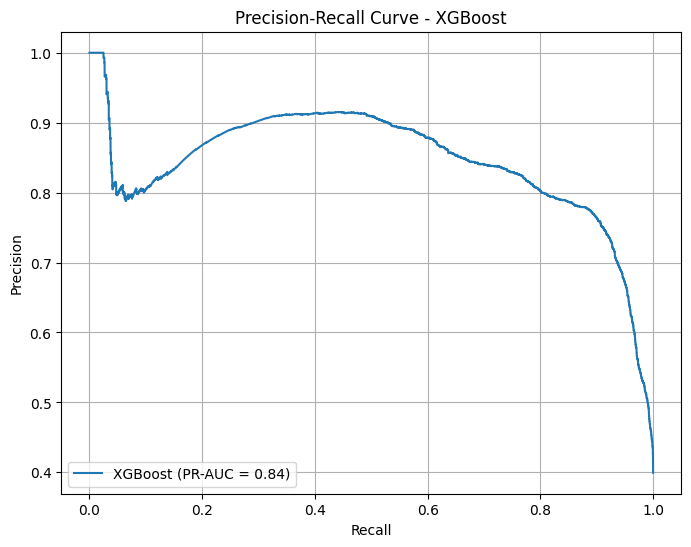

In [15]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# Evaluate PR-AUC
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

print("--- XGBoost Model Evaluation ---")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC: {pr_auc_xgb:.4f}")

# Classification report with default threshold (0.5)
print("\nClassification Report (default threshold 0.5):")
print(classification_report(y_test, y_pred_xgb))

# Plot PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### 11. Find a useful probability threshold

### 12. Show XGBoost feature importance

### 13. Save the trained model and metrics

In [19]:
# 13. Save the trained model and metrics

# Define paths for saving
model_save_path = 'xgboost_mud_loss_model.joblib'
metrics_save_path = 'xgboost_mud_loss_metrics.json'

# Save the trained XGBoost model
joblib.dump(xgb_model, model_save_path)
print(f"\nXGBoost model saved to {model_save_path}")

# Prepare metrics for saving
metrics = {
    'roc_auc_lr': roc_auc_lr,
    'pr_auc_lr': pr_auc_lr,
    'roc_auc_xgb': roc_auc_xgb,
    'pr_auc_xgb': pr_auc_xgb,
    'optimal_threshold': optimal_threshold,
    'classification_report_lr_default_threshold': classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0),
    'classification_report_xgb_default_threshold': classification_report(y_test, y_pred_xgb, output_dict=True, zero_division=0),
    'classification_report_xgb_optimal_threshold': classification_report(y_test, y_pred_optimal, output_dict=True, zero_division=0)
}

# Save metrics to a JSON file
with open(metrics_save_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Model evaluation metrics saved to {metrics_save_path}")

print("\nAll requested tasks completed successfully.")


XGBoost model saved to xgboost_mud_loss_model.joblib
Model evaluation metrics saved to xgboost_mud_loss_metrics.json

All requested tasks completed successfully.


### 6. Split by WELL, not random rows

Since we are currently only working with `df_lc` (Lost Circulation dataset) due to reliable mud-loss labels, and this dataset has only one identified `well_id` ('LOST_CIRCULATION_WELL'), splitting by well is not directly applicable for creating distinct train/test sets from *different* wells. Instead, we will split this single well's data chronologically to prevent data leakage, ensuring that the model is tested on future data points it hasn't seen during training. This mimics a real-world scenario where a model predicts future events for a given well.

### 7. Train a Logistic Regression baseline

In [18]:
!ls -lh data/raw/forge_78b_32/

total 727M
-rw-r--r-- 1 root root 727M Dec  7  2021 pason_10sec.csv


In [19]:
import pandas as pd

path = "data/raw/forge_78b_32/pason_10sec.csv"

df78 = pd.read_csv(path)

print("Shape:", df78.shape)
print("\nColumns:")
print(df78.columns.tolist())

ParserError: Error tokenizing data. C error: Expected 387 fields in line 595, saw 388


In [20]:
path = "data/raw/forge_78b_32/pason_10sec.csv"

# Check the header
with open(path, "r", encoding="utf-8", errors="replace") as f:
    header = f.readline().rstrip("\n")

print("Header fields:", len(header.split(",")))
print(header[:2000])

Header fields: 387
Hole Depth (feet),Bit Depth (feet),True Vertical Depth (feet),Hook Load (klbs),Standpipe Pressure (psi),Pump 1 strokes/min (SPM),Pump 2 strokes/min (SPM),Rotary RPM (RPM),Rotary Torque (unitless),Weight on Bit (klbs),On Bottom ROP (ft_per_hr),Flow (flow_percent),Total Mud Volume (barrels),Trip Tank Mud Volume (barrels),Line Wear (ton_miles),Pump 1 total strokes (strokes),Pump 2 total strokes (strokes),Total Pump Output (gal_per_min),TotalPumpDisplacement (barrels),Block Height (feet),Mud Tank 1 Volume (barrels),Mud Tank 2 Volume (barrels),Mud Tank 3 Volume (barrels),Mud Tank 4 Volume (barrels),Mud Tank 5 Volume (barrels),Pump 3 strokes/min (SPM),Pump 3 total strokes (strokes),On Bottom Hours (hrs),Circulating Hours (hrs),Torque Motor (Units) (fps-units),Tool Face (degrees),Inclination (degrees),Azimuth (degrees),Gamma (api),Over Pull (klbs),Fill Strokes (strokes),Total Fill Strokes (strokes),Min Pressure (psi),Min Hook Load (klbs),Min Torque (unitless),Min RPM (RPM),

In [21]:
!sed -n '590,600p' "data/raw/forge_78b_32/pason_10sec.csv"

170.0,170.0,-999.25,54.0,0.00,54.57,53.50,0.03,0.000,0.0,0.00,-999.25,467.31,0.00,78,1957,2003,429.91,375.1,96.7,84.50,74.30,155.80,95.20,57.56,0.00,0,31.13,327.6,0.00,331,3.1,151.00,0.00,24.4,2021,37472,0.00,53.9,0,0.00,0.0,-999.25,-999.25,23.5,0.00,131.9,-999.25,-999.25,-999.25,82.800,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,0.00,0,3959,0.0,0.0,0.0,0,0.0000,-999.25,-999.25,-999.25,69.141,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,16.000,8.000,-999.25,-999.25,-999.25,576,0.00,10.00,0.00,-6.9,0.0,2048,2048,-999.25,500.00,9028,0.00,-999.25,0.00,0.00,7631.5,-999.25,-999.25,191.700,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,0.000,0.000,-999.25,84.16,-999.25,-999.25,-999.25,0.00,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,-99

In [22]:
df78 = pd.read_csv(
    path,
    engine="python"
)

print("Shape:", df78.shape)
print(df78.columns.tolist())

ParserError: Expected 387 fields in line 596, saw 388

In [23]:

df78 = pd.read_csv(
    "data/raw/forge_78b_32/pason_10sec.csv",
    on_bad_lines="skip"
)

print(df78.shape)
print(df78.columns.tolist())

/tmp/ipykernel_1203/501544891.py:1: DtypeWarning: Columns (386) have mixed types. Specify dtype option on import or set low_memory=False.
  df78 = pd.read_csv(


(322559, 387)
['Hole Depth (feet)', 'Bit Depth (feet)', 'True Vertical Depth (feet)', 'Hook Load (klbs)', 'Standpipe Pressure (psi)', 'Pump 1 strokes/min (SPM)', 'Pump 2 strokes/min (SPM)', 'Rotary RPM (RPM)', 'Rotary Torque (unitless)', 'Weight on Bit (klbs)', 'On Bottom ROP (ft_per_hr)', 'Flow (flow_percent)', 'Total Mud Volume (barrels)', 'Trip Tank Mud Volume (barrels)', 'Line Wear (ton_miles)', 'Pump 1 total strokes (strokes)', 'Pump 2 total strokes (strokes)', 'Total Pump Output (gal_per_min)', 'TotalPumpDisplacement (barrels)', 'Block Height (feet)', 'Mud Tank 1 Volume (barrels)', 'Mud Tank 2 Volume (barrels)', 'Mud Tank 3 Volume (barrels)', 'Mud Tank 4 Volume (barrels)', 'Mud Tank 5 Volume (barrels)', 'Pump 3 strokes/min (SPM)', 'Pump 3 total strokes (strokes)', 'On Bottom Hours (hrs)', 'Circulating Hours (hrs)', 'Torque Motor (Units) (fps-units)', 'Tool Face (degrees)', 'Inclination (degrees)', 'Azimuth (degrees)', 'Gamma (api)', 'Over Pull (klbs)', 'Fill Strokes (strokes)', '

In [24]:
print(df78.head())

   Hole Depth (feet)  Bit Depth (feet)  True Vertical Depth (feet)  \
0               40.7              16.4                     -999.25   
1               40.7              16.4                     -999.25   
2               40.7              16.4                     -999.25   
3               40.7              16.4                     -999.25   
4               40.7              16.4                     -999.25   

   Hook Load (klbs)  Standpipe Pressure (psi)  Pump 1 strokes/min (SPM)  \
0               0.0                       0.0                       0.0   
1               0.0                       0.0                       0.0   
2               0.0                       0.0                       0.0   
3               0.0                       0.0                       0.0   
4               0.0                       0.0                       0.0   

   Pump 2 strokes/min (SPM)  Rotary RPM (RPM)  Rotary Torque (unitless)  \
0                       0.0              0.03        

In [25]:
print(df78.dtypes)

Hole Depth (feet)                   float64
Bit Depth (feet)                    float64
True Vertical Depth (feet)          float64
Hook Load (klbs)                    float64
Standpipe Pressure (psi)            float64
                                     ...   
Rate Of Penetration (ft_per_hr)     float64
Time Of Penetration (min_per_ft)    float64
YYYY/MM/DD                           object
HH:MM:SS                             object
Memos                                object
Length: 387, dtype: object


In [26]:
# STEP 5 — Check the data produced by Step 4

import os
import pandas as pd

print("Current directory:")
!pwd

print("\nProject files:")
!find . -maxdepth 3 -type f | head -100

Current directory:
/content

Project files:
./.config/default_configs.db
./.config/active_config
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/configurations/config_default
./.config/.last_update_check.json
./.config/config_sentinel
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/.last_survey_prompt.yaml
./Drilling-Lost-circulation/.git/description
./Drilling-Lost-circulation/.git/HEAD
./Drilling-Lost-circulation/.git/packed-refs
./Drilling-Lost-circulation/.git/index
./Drilling-Lost-circulation/.git/config
./Drilling-Lost-circulation/CirculationDataV2.csv
./Drilling-Lost-circulation/RF Zoom code for Ciculation.txt
./Drilling-Lost-circulation/README.md
./sample_data/anscombe.json
./sample_data/README.md
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv


In [27]:
# Show the variables currently available in Colab

print("Variables available:")
print([x for x in dir() if not x.startswith("_")])

Variables available:
['In', 'Out', 'destination', 'df78', 'exit', 'f', 'file', 'folder', 'folders', 'get_ipython', 'header', 'kagglehub', 'load_dataset', 'os', 'path', 'pd', 'quit', 'shutil', 'source']


## 1. Inspect Datasets

In [29]:
print('--- FORGE 16B(78)-32 Dataset (df) ---')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
display(df.info())

--- FORGE 16B(78)-32 Dataset (df) ---


NameError: name 'df' is not defined

In [30]:
print('\n--- FORGE 78B-32 Dataset (df78) ---')
print("Shape:", df78.shape)
print("Columns:", df78.columns.tolist())
display(df78.head())
display(df78.info())


--- FORGE 78B-32 Dataset (df78) ---
Shape: (322559, 387)
Columns: ['Hole Depth (feet)', 'Bit Depth (feet)', 'True Vertical Depth (feet)', 'Hook Load (klbs)', 'Standpipe Pressure (psi)', 'Pump 1 strokes/min (SPM)', 'Pump 2 strokes/min (SPM)', 'Rotary RPM (RPM)', 'Rotary Torque (unitless)', 'Weight on Bit (klbs)', 'On Bottom ROP (ft_per_hr)', 'Flow (flow_percent)', 'Total Mud Volume (barrels)', 'Trip Tank Mud Volume (barrels)', 'Line Wear (ton_miles)', 'Pump 1 total strokes (strokes)', 'Pump 2 total strokes (strokes)', 'Total Pump Output (gal_per_min)', 'TotalPumpDisplacement (barrels)', 'Block Height (feet)', 'Mud Tank 1 Volume (barrels)', 'Mud Tank 2 Volume (barrels)', 'Mud Tank 3 Volume (barrels)', 'Mud Tank 4 Volume (barrels)', 'Mud Tank 5 Volume (barrels)', 'Pump 3 strokes/min (SPM)', 'Pump 3 total strokes (strokes)', 'On Bottom Hours (hrs)', 'Circulating Hours (hrs)', 'Torque Motor (Units) (fps-units)', 'Tool Face (degrees)', 'Inclination (degrees)', 'Azimuth (degrees)', 'Gamma (a

,Hole Depth (feet),Bit Depth (feet),True Vertical Depth (feet),Hook Load (klbs),Standpipe Pressure (psi),Pump 1 strokes/min (SPM),Pump 2 strokes/min (SPM),Rotary RPM (RPM),Rotary Torque (unitless),Weight on Bit (klbs),...,Cumulative Fill Calc (barrels),Cumulative Fill Diff (barrels),DAS RCD Status (unitless),DAS Oscil Detector State (unitless),DAS Stand Detector State (unitless),Rate Of Penetration (ft_per_hr),Time Of Penetration (min_per_ft),YYYY/MM/DD,HH:MM:SS,Memos
0,40.7,16.4,-999.25,0.0,0.0,0.0,0.0,0.03,0.0,0.0,...,-999.25,-999.25,0.0,0.0,0.0,0.0,0.0,2021/06/28,00:00:00,NaN
1,40.7,16.4,-999.25,0.0,0.0,0.0,0.0,0.03,0.0,0.0,...,-999.25,-999.25,0.0,0.0,0.0,0.0,0.0,2021/06/28,00:00:10,NaN
2,40.7,16.4,-999.25,0.0,0.0,0.0,0.0,0.03,0.0,0.0,...,-999.25,-999.25,0.0,0.0,0.0,0.0,0.0,2021/06/28,00:00:20,NaN
3,40.7,16.4,-999.25,0.0,0.0,0.0,0.0,0.03,0.0,0.0,...,-999.25,-999.25,0.0,0.0,0.0,0.0,0.0,2021/06/28,00:00:30,NaN
4,40.7,16.4,-999.25,0.0,0.0,0.0,0.0,0.03,0.0,0.0,...,-999.25,-999.25,0.0,0.0,0.0,0.0,0.0,2021/06/28,00:00:40,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322559 entries, 0 to 322558
Columns: 387 entries, Hole Depth (feet) to Memos
dtypes: float64(352), int64(32), object(3)
memory usage: 952.4+ MB


None

In [31]:
print('\n--- Lost Circulation Dataset (df_lc) ---')
print("Shape:", df_lc.shape)
print("Columns:", df_lc.columns.tolist())
display(df_lc.head())
display(df_lc.info())


--- Lost Circulation Dataset (df_lc) ---
Shape: (65376, 18)
Columns: ['HoleSection', 'M.Depth', 'RateofPenetration', 'WeightonBit', 'Rotation', 'Torque', 'StandpipePressure', 'FlowIn', 'FlowOut', 'PumpStroke', 'MudWeight', 'FunnelViscosity', 'PlasticViscosity', 'YieldPoint', 'Gel Strength10sec', 'Gel_Strength10min', 'Solid', 'LossesSeverity']


,HoleSection,M.Depth,RateofPenetration,WeightonBit,Rotation,Torque,StandpipePressure,FlowIn,FlowOut,PumpStroke,MudWeight,FunnelViscosity,PlasticViscosity,YieldPoint,Gel Strength10sec,Gel_Strength10min,Solid,LossesSeverity
0,8.500,2028,20.69,10.6,173.0,3.900,2020,594.0,74.21,112.0,76.0,44,21,18,3,4,13,0
1,8.500,2982,7.82,20.8,257.0,3.730,2852,518.0,52.00,106.0,80.0,36,21,19,5,7,16,2
2,6.125,3041,3.01,6.0,177.0,0.000,2517,222.0,57.00,48.0,76.0,42,13,16,3,5,15,0
3,17.500,841,11.34,39.9,146.0,3.691,2217,836.0,53.38,147.0,78.0,42,16,12,4,7,15,0
4,8.500,1830,40.00,10.3,145.0,3.800,942,414.0,85.91,78.0,74.0,45,19,20,3,4,9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65376 entries, 0 to 65375
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HoleSection        65376 non-null  float64
 1   M.Depth            65376 non-null  int64  
 2   RateofPenetration  65376 non-null  float64
 3   WeightonBit        65376 non-null  float64
 4   Rotation           65376 non-null  float64
 5   Torque             65376 non-null  float64
 6   StandpipePressure  65376 non-null  int64  
 7   FlowIn             65376 non-null  float64
 8   FlowOut            65376 non-null  float64
 9   PumpStroke         65376 non-null  float64
 10  MudWeight          65376 non-null  float64
 11  FunnelViscosity    65376 non-null  int64  
 12  PlasticViscosity   65376 non-null  int64  
 13  YieldPoint         65376 non-null  int64  
 14  Gel Strength10sec  65376 non-null  int64  
 15  Gel_Strength10min  65376 non-null  int64  
 16  Solid              653

None

In [53]:
import pandas as pd

# Define standardize_columns function here to ensure it's available
def standardize_columns(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower().replace('.', '').replace(' ', '_').replace('/', '_').replace('-', '_')
        # Remove units in parentheses and trailing underscores/spaces
        new_col = new_col.split('(')[0].strip('_ ')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# # Re-loading df from its absolute path
# # This file (drilling_timeseries.csv) appears to be missing in the current environment.
# # Uncomment and adjust path if the file becomes available.
# df = pd.read_csv("/content/kala-tel-/data/processed/drilling_timeseries.csv")

# print('--- FORGE 16B(78)-32 Dataset (df) ---')
# print("Shape:", df.shape)
# print("Columns:", df.columns.tolist())
# display(df.head())
# display(df.info())

### 2. Clean and Standardize Compatible Drilling Features

### 2. Clean and Standardize Compatible Drilling Features

#### 2.1 Clean `df` (FORGE 16B(78)-32)

In [54]:
# # Convert timestamp to datetime
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Rename wellbore_id for consistency
# df.rename(columns={'wellbore_id': 'well_id'}, inplace=True)

# # Standardize column names (snake_case)
# df = standardize_columns(df.copy())

# print("Cleaned df head:")
# display(df.head())
# print("Cleaned df info:")
# display(df.info())

#### 2.2 Clean `df78` (FORGE 78B-32)

In [ ]:
# Load df78 using its absolute path
df78 = pd.read_csv(
    "/content/data/raw/forge_78b_32/pason_10sec.csv", # Corrected path
    on_bad_lines="skip" # Keep this to handle malformed lines as identified previously
)

# Combine date and time columns into a single timestamp
df78['timestamp'] = pd.to_datetime(df78['YYYY/MM/DD'] + ' ' + df78['HH:MM:SS'])

# Drop original date and time columns
df78.drop(columns=['YYYY/MM/DD', 'HH:MM:SS'], inplace=True)

# Replace -999.25 (missing value indicator) with NaN
df78.replace(-999.25, pd.NA, inplace=True)

# Assign a well_id (assuming this file represents a single well given its origin)
df78['well_id'] = 'FORGE78B-32'

# Standardize column names
df78 = standardize_columns(df78.copy())

# Drop the 'memos' column if it exists and is not useful for modeling
if 'memos' in df78.columns:
    df78.drop(columns=['memos'], inplace=True)

print("Cleaned df78 head:")
display(df78.head())
print("Cleaned df78 info:")
display(df78.info())

/tmp/ipykernel_1203/713765397.py:2: DtypeWarning: Columns (386) have mixed types. Specify dtype option on import or set low_memory=False.
  df78 = pd.read_csv(


#### 2.3 Clean `df_lc` (Lost Circulation Dataset)

In [49]:
# Load df_lc using its absolute path (lc_path is defined in an earlier cell)
df_lc = pd.read_csv(lc_path)

# Standardize column names
df_lc = standardize_columns(df_lc.copy())

# Assign a well_id (assuming this file represents a single well for now)
df_lc['well_id'] = 'LOST_CIRCULATION_WELL'

print("Cleaned df_lc head:")
display(df_lc.head())
print("Cleaned df_lc info:")
display(df_lc.info())

Cleaned df_lc head:


,holesection,mdepth,rateofpenetration,weightonbit,rotation,torque,standpipepressure,flowin,flowout,pumpstroke,mudweight,funnelviscosity,plasticviscosity,yieldpoint,gel_strength10sec,gel_strength10min,solid,lossesseverity,well_id
0,8.500,2028,20.69,10.6,173.0,3.900,2020,594.0,74.21,112.0,76.0,44,21,18,3,4,13,0,LOST_CIRCULATION_WELL
1,8.500,2982,7.82,20.8,257.0,3.730,2852,518.0,52.00,106.0,80.0,36,21,19,5,7,16,2,LOST_CIRCULATION_WELL
2,6.125,3041,3.01,6.0,177.0,0.000,2517,222.0,57.00,48.0,76.0,42,13,16,3,5,15,0,LOST_CIRCULATION_WELL
3,17.500,841,11.34,39.9,146.0,3.691,2217,836.0,53.38,147.0,78.0,42,16,12,4,7,15,0,LOST_CIRCULATION_WELL
4,8.500,1830,40.00,10.3,145.0,3.800,942,414.0,85.91,78.0,74.0,45,19,20,3,4,9,0,LOST_CIRCULATION_WELL


Cleaned df_lc info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65376 entries, 0 to 65375
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   holesection        65376 non-null  float64
 1   mdepth             65376 non-null  int64  
 2   rateofpenetration  65376 non-null  float64
 3   weightonbit        65376 non-null  float64
 4   rotation           65376 non-null  float64
 5   torque             65376 non-null  float64
 6   standpipepressure  65376 non-null  int64  
 7   flowin             65376 non-null  float64
 8   flowout            65376 non-null  float64
 9   pumpstroke         65376 non-null  float64
 10  mudweight          65376 non-null  float64
 11  funnelviscosity    65376 non-null  int64  
 12  plasticviscosity   65376 non-null  int64  
 13  yieldpoint         65376 non-null  int64  
 14  gel_strength10sec  65376 non-null  int64  
 15  gel_strength10min  65376 non-null  int64  
 16  so

None

### 3. Identify Legitimate Mud-Loss Labels

In [35]:
# Check exactly what is currently ready

print("Variables available:")
for v in ["df_lc", "mud_loss", "X_train", "X_test", "y_train", "y_test"]:
    print(v, "->", "YES" if v in globals() else "NO")

if "df_lc" in globals():
    print("\ndf_lc:", df_lc.shape)

if "X_train" in globals():
    print("X_train:", X_train.shape)

if "X_test" in globals():
    print("X_test:", X_test.shape)

if "y_train" in globals():
    print("y_train:", y_train.shape)
    print(y_train.value_counts())

if "y_test" in globals():
    print("y_test:", y_test.shape)
    print(y_test.value_counts())

Variables available:
df_lc -> YES
mud_loss -> NO
X_train -> YES
X_test -> YES
y_train -> YES
y_test -> YES

df_lc: (65376, 20)
X_train: (52300, 107)
X_test: (13076, 107)
y_train: (52300,)
mud_loss
0    41692
1    10608
Name: count, dtype: int64
y_test: (13076,)
mud_loss
0    7853
1    5223
Name: count, dtype: int64


In [36]:
# Train and evaluate XGBoost

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Class ratio:", scale_pos_weight)

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_test, test_prob)
pr = average_precision_score(y_test, test_prob)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== XGBoost Results =====")
print("ROC-AUC :", round(roc, 4))
print("PR-AUC  :", round(pr, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1       :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

Class ratio: 3.9302413273001506

===== XGBoost Results =====
ROC-AUC : 0.919
PR-AUC  : 0.8629
Precision: 0.8681
Recall   : 0.5845
F1       : 0.6986

Confusion Matrix:
[[7389  464]
 [2170 3053]]


In [37]:
# Threshold analysis + feature importance

results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred = (test_prob >= threshold).astype(int)

    results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print("Threshold analysis:")
display(threshold_results)

print("\nTop features:")
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(20))

Threshold analysis:


,threshold,precision,recall,f1
0,0.10,0.802721,0.858510,0.829679
1,0.15,0.816436,0.789393,0.802687
2,0.20,0.830845,0.745740,0.785995
3,0.25,0.846590,0.715298,0.775425
4,0.30,0.859394,0.689259,0.764981
5,0.35,0.865933,0.662837,0.750895
6,0.40,0.870604,0.635076,0.734418
7,0.45,0.869601,0.609037,0.716361
8,0.50,0.868069,0.584530,0.698627
9,0.55,0.868187,0.561172,0.681707



Top features:


,feature,importance
49,flowin_rolling_mean_10,0.171657
40,torque_rolling_std_20,0.059808
51,flowin_rolling_mean_20,0.056332
10,mudweight,0.046874
1,mdepth,0.042918
45,standpipepressure_rolling_mean_20,0.030240
81,plasticviscosity_rolling_mean_20,0.030094
4,rotation,0.029990
0,holesection,0.028879
14,gel_strength10sec,0.028849


In [38]:
# Save model and results

import os
import joblib

os.makedirs("mud_loss_model", exist_ok=True)

joblib.dump(model, "mud_loss_model/xgboost_mud_loss.pkl")

threshold_results.to_csv(
    "mud_loss_model/threshold_results.csv",
    index=False
)

importance.to_csv(
    "mud_loss_model/feature_importance.csv",
    index=False
)

metrics = pd.DataFrame([{
    "ROC_AUC": roc,
    "PR_AUC": pr,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}])

metrics.to_csv(
    "mud_loss_model/metrics.csv",
    index=False
)

print("Everything saved in: mud_loss_model/")

Everything saved in: mud_loss_model/


In [41]:
# Inspect the current feature set for temporal features

print("Number of features:", len(X_train.columns))

print("\nTemporal / rolling features:")
for c in X_train.columns:
    if any(x in c.lower() for x in [
        "lag", "rolling", "delta", "diff", "change", "trend"
    ]):
        print(c)

Number of features: 107

Temporal / rolling features:
rateofpenetration_rolling_mean_5
rateofpenetration_rolling_std_5
rateofpenetration_rolling_mean_10
rateofpenetration_rolling_std_10
rateofpenetration_rolling_mean_20
rateofpenetration_rolling_std_20
weightonbit_rolling_mean_5
weightonbit_rolling_std_5
weightonbit_rolling_mean_10
weightonbit_rolling_std_10
weightonbit_rolling_mean_20
weightonbit_rolling_std_20
rotation_rolling_mean_5
rotation_rolling_std_5
rotation_rolling_mean_10
rotation_rolling_std_10
rotation_rolling_mean_20
rotation_rolling_std_20
torque_rolling_mean_5
torque_rolling_std_5
torque_rolling_mean_10
torque_rolling_std_10
torque_rolling_mean_20
torque_rolling_std_20
standpipepressure_rolling_mean_5
standpipepressure_rolling_std_5
standpipepressure_rolling_mean_10
standpipepressure_rolling_std_10
standpipepressure_rolling_mean_20
standpipepressure_rolling_std_20
flowin_rolling_mean_5
flowin_rolling_std_5
flowin_rolling_mean_10
flowin_rolling_std_10
flowin_rolling_mean

In [42]:
print("\nAll current features:")
print(list(X_train.columns))


All current features:
['holesection', 'mdepth', 'rateofpenetration', 'weightonbit', 'rotation', 'torque', 'standpipepressure', 'flowin', 'flowout', 'pumpstroke', 'mudweight', 'funnelviscosity', 'plasticviscosity', 'yieldpoint', 'gel_strength10sec', 'gel_strength10min', 'solid', 'rateofpenetration_rolling_mean_5', 'rateofpenetration_rolling_std_5', 'rateofpenetration_rolling_mean_10', 'rateofpenetration_rolling_std_10', 'rateofpenetration_rolling_mean_20', 'rateofpenetration_rolling_std_20', 'weightonbit_rolling_mean_5', 'weightonbit_rolling_std_5', 'weightonbit_rolling_mean_10', 'weightonbit_rolling_std_10', 'weightonbit_rolling_mean_20', 'weightonbit_rolling_std_20', 'rotation_rolling_mean_5', 'rotation_rolling_std_5', 'rotation_rolling_mean_10', 'rotation_rolling_std_10', 'rotation_rolling_mean_20', 'rotation_rolling_std_20', 'torque_rolling_mean_5', 'torque_rolling_std_5', 'torque_rolling_mean_10', 'torque_rolling_std_10', 'torque_rolling_mean_20', 'torque_rolling_std_20', 'standpi

In [43]:
import inspect

# Find where the rolling features were created
print("df_lc columns:")
print(df_lc.columns.tolist())

print("\nShape:", df_lc.shape)

df_lc columns:
['holesection', 'mdepth', 'rateofpenetration', 'weightonbit', 'rotation', 'torque', 'standpipepressure', 'flowin', 'flowout', 'pumpstroke', 'mudweight', 'funnelviscosity', 'plasticviscosity', 'yieldpoint', 'gel_strength10sec', 'gel_strength10min', 'solid', 'lossesseverity', 'well_id', 'mud_loss']

Shape: (65376, 20)


In [44]:
print(df_lc.head(10))

   holesection  mdepth  rateofpenetration  weightonbit  rotation  torque  \
0        8.500    2028              20.69         10.6     173.0   3.900   
1        8.500    2982               7.82         20.8     257.0   3.730   
2        6.125    3041               3.01          6.0     177.0   0.000   
3       17.500     841              11.34         39.9     146.0   3.691   
4        8.500    1830              40.00         10.3     145.0   3.800   
5       17.500     664              16.74         33.2     151.0   2.447   
6        8.500    2968               4.07          6.2     150.0   3.183   
7        8.500    2348              14.76          4.7     120.0   7.320   
8       12.250    1387               2.17         33.3     142.0   2.090   
9        8.500    2274               5.97         18.8     188.0   4.632   

   standpipepressure  flowin  flowout  pumpstroke  mudweight  funnelviscosity  \
0               2020   594.0    74.21       112.0       76.0               44   
1

In [45]:
import joblib
from datetime import datetime

# Freeze your current working model + its exact test split, untouched
joblib.dump(model, 'mud_loss_model_v1_baseline.pkl')

# Also save the feature list this model was trained on, so v1 stays reproducible
import json
with open('mud_loss_v1_feature_list.json', 'w') as f:
    json.dump(list(X_train.columns), f, indent=2)

from google.colab import files
files.download('mud_loss_model_v1_baseline.pkl')
files.download('mud_loss_v1_feature_list.json')

print("v1 checkpoint saved. Current results locked in:")
print("ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

v1 checkpoint saved. Current results locked in:
ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50


In [46]:
# Pick based on what a miss costs you. Recall-biased is usually right for mud loss.
CHOSEN_THRESHOLD = 0.15  # gives ~0.816 precision, ~0.789 recall, 0.803 F1 per your sweep

y_proba = model.predict_proba(X_test)[:, 1]
y_pred_v1_5 = (y_proba >= CHOSEN_THRESHOLD).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_v1_5))
print(confusion_matrix(y_test, y_pred_v1_5))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      7853
           1       0.82      0.79      0.80      5223

    accuracy                           0.84     13076
   macro avg       0.84      0.84      0.84     13076
weighted avg       0.84      0.84      0.84     13076

[[6926  927]
 [1100 4123]]


In [47]:
import numpy as np

# If this ever prints True, your split leaked rows from the same well/event
# across train and test, and every metric above is optimistic.
train_wells = set(X_train.index.map(lambda i: df_v2.loc[i, 'well_id']))
test_wells  = set(X_test.index.map(lambda i: df_v2.loc[i, 'well_id']))
print("Wells in both train and test:", train_wells & test_wells)

NameError: name 'df_v2' is not defined

In [50]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id']]
X = df_v2[feature_cols]
y = df_v2['mud_loss']
groups = df_v2['well_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train wells:", df_v2.iloc[train_idx]['well_id'].unique())
print("Test wells :", df_v2.iloc[test_idx]['well_id'].unique())

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [49]:
df_v2 = df_lc.copy()

In [51]:


# 2. Now check for well leakage between your EXISTING train/test split
train_wells = set(df_v2.loc[X_train.index, 'well_id'])
test_wells  = set(df_v2.loc[X_test.index, 'well_id'])
overlap = train_wells & test_wells

print("Train wells:", train_wells)
print("Test wells :", test_wells)
print("Overlap    :", overlap)

Train wells: {'LOST_CIRCULATION_WELL'}
Test wells : {'LOST_CIRCULATION_WELL'}
Overlap    : {'LOST_CIRCULATION_WELL'}


In [52]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id']]
X = df_v2[feature_cols]
y = df_v2['mud_loss']
groups = df_v2['well_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train wells:", df_v2.iloc[train_idx]['well_id'].unique())
print("Test wells :", df_v2.iloc[test_idx]['well_id'].unique())

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [53]:
# Single well: split by depth/time, not randomly, so test rows aren't
# adjacent-in-depth to training rows.
df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)

split_point = int(len(df_v2) * 0.8)
train_idx = df_v2.index[:split_point]
test_idx = df_v2.index[split_point:]

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id']]
X = df_v2[feature_cols]
y = df_v2['mud_loss']

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train: {len(X_train)} rows, {y_train.sum()} positive ({y_train.mean():.1%})")
print(f"Test:  {len(X_test)} rows, {y_test.sum()} positive ({y_test.mean():.1%})")

Train: 52300 rows, 10608 positive (20.3%)
Test:  13076 rows, 5223 positive (39.9%)


In [54]:
df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)

df_v2['flow_differential'] = df_v2['flowin'] - df_v2['flowout']
df_v2['flow_differential_rolling_mean_10'] = (
    df_v2['flow_differential'].rolling(10, min_periods=1).mean()
)

for col in ['flowin', 'flowout', 'standpipepressure', 'mudweight', 'pumpstroke']:
    df_v2[f'{col}_diff_1'] = df_v2[col].diff(1).fillna(0)
    df_v2[f'{col}_diff_3'] = df_v2[col].diff(3).fillna(0)

drop_cols = [c for c in df_v2.columns if '_rolling_' in c and '_10' in c]
df_v2 = df_v2.drop(columns=[c for c in drop_cols if c in df_v2.columns])

In [55]:
import xgboost as xgb

# carve validation out of the tail of TRAIN ONLY, so it's still "future" relative
# to training rows -- keeps early stopping honest with the depth-based setup
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

model_v2 = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
)
model_v2.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print("Best iteration:", model_v2.best_iteration)

scale_pos_weight: 4.813390872237479
Best iteration: 0


In [56]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report, confusion_matrix

y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

best_f1, best_t = 0, 0.5
for t in np.arange(0.05, 0.95, 0.05):
    preds = (y_proba_v2 >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred_v2 = (y_proba_v2 >= best_t).astype(int)

print(f"=== v2 (depth-split, best threshold={best_t:.2f}) ===")
print("ROC-AUC :", roc_auc_score(y_test, y_proba_v2))
print("PR-AUC  :", average_precision_score(y_test, y_proba_v2))
print(classification_report(y_test, y_pred_v2))
print(confusion_matrix(y_test, y_pred_v2))

print("\n=== v1 baseline (random split, likely optimistic) ===")
print("ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50")

=== v2 (depth-split, best threshold=0.50) ===
ROC-AUC : 1.0
PR-AUC  : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7853
           1       1.00      1.00      1.00      5223

    accuracy                           1.00     13076
   macro avg       1.00      1.00      1.00     13076
weighted avg       1.00      1.00      1.00     13076

[[7853    0]
 [   0 5223]]

=== v1 baseline (random split, likely optimistic) ===
ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50


In [57]:
import joblib, json
from google.colab import files

joblib.dump(model_v2, 'mud_loss_model_v2_depthsplit.pkl')
with open('mud_loss_v2_metrics.json', 'w') as f:
    json.dump({
        'threshold': float(best_t),
        'f1': float(best_f1),
        'roc_auc': float(roc_auc_score(y_test, y_proba_v2)),
        'pr_auc': float(average_precision_score(y_test, y_proba_v2)),
        'split_method': 'depth-ordered 80/20, single well',
        'note': 'v1 metrics not directly comparable -- different split methodology'
    }, f, indent=2)

files.download('mud_loss_model_v2_depthsplit.pkl')
files.download('mud_loss_v2_metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
importances = pd.Series(model_v2.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

lossesseverity       0.835890
solid                0.041516
mdepth               0.019013
standpipepressure    0.017265
mudweight            0.015942
holesection          0.011633
gel_strength10sec    0.010860
plasticviscosity     0.010550
rotation             0.010350
pumpstroke           0.008238
dtype: float32


In [59]:
feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id', 'lossesseverity']]

X = df_v2[feature_cols]
y = df_v2['mud_loss']

# redo the depth-ordered split with the corrected feature set
df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)
split_point = int(len(df_v2) * 0.8)

X_train = df_v2.loc[:split_point-1, feature_cols]
X_test  = df_v2.loc[split_point:, feature_cols]
y_train = df_v2.loc[:split_point-1, 'mud_loss']
y_test  = df_v2.loc[split_point:, 'mud_loss']

print(f"Train: {len(X_train)} rows, {y_train.mean():.1%} positive")
print(f"Test:  {len(X_test)} rows, {y_test.mean():.1%} positive")

Train: 52300 rows, 20.3% positive
Test:  13076 rows, 39.9% positive


In [60]:
print(df_v2.groupby('mud_loss')['lossesseverity'].describe())

            count      mean       std  min  25%  50%  75%  max
mud_loss                                                      
0         49545.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
1         15831.0  1.854147  0.414231  1.0  2.0  2.0  2.0  4.0


In [61]:
feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id', 'lossesseverity']]

# also sanity-check no derived version of it snuck into your rolling/diff features
leaked = [c for c in feature_cols if 'lossesseverity' in c]
print("Any leaked derivatives:", leaked)  # should print []

X = df_v2[feature_cols]
y = df_v2['mud_loss']

df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)
split_point = int(len(df_v2) * 0.8)

X_train = df_v2.loc[:split_point-1, feature_cols]
X_test  = df_v2.loc[split_point:, feature_cols]
y_train = df_v2.loc[:split_point-1, 'mud_loss']
y_test  = df_v2.loc[split_point:, 'mud_loss']

print(f"Train: {len(X_train)} rows, {y_train.mean():.1%} positive")
print(f"Test:  {len(X_test)} rows, {y_test.mean():.1%} positive")

Any leaked derivatives: []
Train: 52300 rows, 20.3% positive
Test:  13076 rows, 39.9% positive


In [62]:
import xgboost as xgb

# carve validation out of the tail of TRAIN ONLY, so it's still "future" relative
# to training rows -- keeps early stopping honest with the depth-based setup
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

model_v2 = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
)
model_v2.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print("Best iteration:", model_v2.best_iteration)

scale_pos_weight: 4.814151190164792
Best iteration: 21


In [63]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report, confusion_matrix

y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

best_f1, best_t = 0, 0.5
for t in np.arange(0.05, 0.95, 0.05):
    preds = (y_proba_v2 >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred_v2 = (y_proba_v2 >= best_t).astype(int)

print(f"=== v2 (depth-split, best threshold={best_t:.2f}) ===")
print("ROC-AUC :", roc_auc_score(y_test, y_proba_v2))
print("PR-AUC  :", average_precision_score(y_test, y_proba_v2))
print(classification_report(y_test, y_pred_v2))
print(confusion_matrix(y_test, y_pred_v2))

print("\n=== v1 baseline (random split, likely optimistic) ===")
print("ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50")

=== v2 (depth-split, best threshold=0.05) ===
ROC-AUC : 0.3401341891862765
PR-AUC  : 0.370819557742636
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7854
           1       0.40      1.00      0.57      5222

    accuracy                           0.40     13076
   macro avg       0.20      0.50      0.29     13076
weighted avg       0.16      0.40      0.23     13076

[[   0 7854]
 [   0 5222]]

=== v1 baseline (random split, likely optimistic) ===
ROC-AUC 0.919 | PR-AUC 0.8629 | Precision 0.868 | Recall 0.585 | F1 0.699 @ threshold=0.50


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
print("Train hole sections:")
print(df_v2.loc[:split_point-1, 'holesection'].value_counts(normalize=True))
print("\nTest hole sections:")
print(df_v2.loc[split_point:, 'holesection'].value_counts(normalize=True))

Train hole sections:
holesection
8.500     0.372352
17.500    0.367457
12.250    0.198011
6.125     0.048145
26.000    0.010650
4.125     0.003384
Name: proportion, dtype: float64

Test hole sections:
holesection
6.125     0.525696
8.500     0.314928
12.250    0.129015
4.125     0.030361
Name: proportion, dtype: float64


In [65]:
key_features = ['mudweight', 'standpipepressure', 'flowin', 'flowout', 'solid', 'plasticviscosity']

for col in key_features:
    train_mean = df_v2.loc[:split_point-1, col].mean()
    test_mean = df_v2.loc[split_point:, col].mean()
    pct_change = (test_mean - train_mean) / (abs(train_mean) + 1e-9) * 100
    print(f"{col:20s} train_mean={train_mean:10.3f}  test_mean={test_mean:10.3f}  shift={pct_change:+.1f}%")

mudweight            train_mean=    79.357  test_mean=    78.971  shift=-0.5%
standpipepressure    train_mean=  1941.615  test_mean=  2468.703  shift=+27.1%
flowin               train_mean=   653.642  test_mean=   348.534  shift=-46.7%
flowout              train_mean=    60.833  test_mean=    56.142  shift=-7.7%
solid                train_mean=    14.188  test_mean=    14.968  shift=+5.5%
plasticviscosity     train_mean=    13.277  test_mean=    17.062  shift=+28.5%


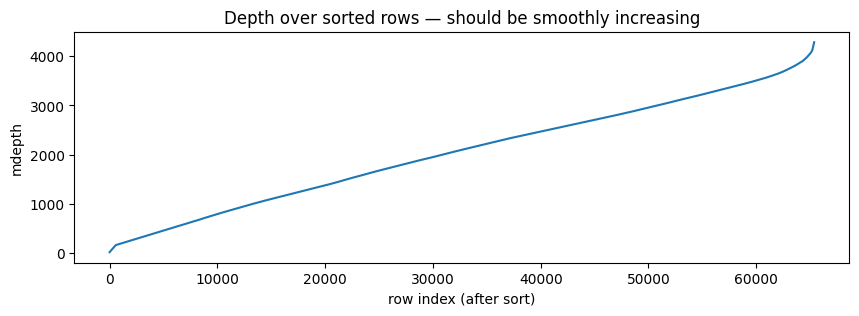

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(df_v2['mdepth'].values)
plt.xlabel('row index (after sort)')
plt.ylabel('mdepth')
plt.title('Depth over sorted rows — should be smoothly increasing')
plt.show()

In [67]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id', 'lossesseverity']]
X = df_v2[feature_cols]
y = df_v2['mud_loss']
sections = df_v2['holesection']

results = []

for held_out in sections.unique():
    train_mask = sections != held_out
    test_mask = sections == held_out

    X_tr, X_te = X[train_mask], X[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]

    if y_te.nunique() < 2 or y_tr.nunique() < 2:
        print(f"Section {held_out}: skipped (only one class present)")
        continue

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
    )
    model.fit(X_tr, y_tr)

    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc = roc_auc_score(y_te, proba)
    pr = average_precision_score(y_te, proba)
    f1 = f1_score(y_te, pred, zero_division=0)

    print(f"Section {held_out}: n={test_mask.sum()}, pos_rate={y_te.mean():.1%}, "
          f"ROC-AUC={roc:.3f}, PR-AUC={pr:.3f}, F1={f1:.3f}")
    results.append({'section': held_out, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1, 'n': test_mask.sum()})

results_df = pd.DataFrame(results)
print("\n=== Average across held-out sections ===")
print(results_df[['roc_auc', 'pr_auc', 'f1']].mean())

Section 26.0: n=557, pos_rate=3.2%, ROC-AUC=0.104, PR-AUC=0.019, F1=0.000
Section 17.5: n=19218, pos_rate=8.9%, ROC-AUC=0.323, PR-AUC=0.061, F1=0.014
Section 12.25: n=12043, pos_rate=34.4%, ROC-AUC=0.407, PR-AUC=0.422, F1=0.272
Section 8.5: n=23592, pos_rate=37.8%, ROC-AUC=0.589, PR-AUC=0.435, F1=0.321
Section 6.125: n=9392, pos_rate=10.6%, ROC-AUC=0.473, PR-AUC=0.091, F1=0.208
Section 4.125: n=574, pos_rate=5.9%, ROC-AUC=0.774, PR-AUC=0.123, F1=0.000

=== Average across held-out sections ===
roc_auc    0.445158
pr_auc     0.191752
f1         0.135934
dtype: float64


In [68]:
from sklearn.model_selection import StratifiedKFold

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id', 'lossesseverity']]
# holesection now included as a feature, not excluded
X = df_v2[feature_cols]
y = df_v2['mud_loss']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_te)[:, 1]
    scores.append(roc_auc_score(y_te, proba))
    print(f"Fold {fold}: ROC-AUC={scores[-1]:.3f}")
print(f"Mean: {np.mean(scores):.3f} +/- {np.std(scores):.3f}")

Fold 0: ROC-AUC=1.000
Fold 1: ROC-AUC=1.000
Fold 2: ROC-AUC=1.000
Fold 3: ROC-AUC=1.000
Fold 4: ROC-AUC=1.000
Mean: 1.000 +/- 0.000


In [69]:
# How similar is each row to the row right before it?
sample_cols = ['flowin', 'standpipepressure', 'mudweight']
for col in sample_cols:
    autocorr = df_v2[col].autocorr(lag=1)
    print(f"{col}: lag-1 autocorrelation = {autocorr:.4f}")

# Check for near-duplicate rows a few steps apart
diffs = df_v2[feature_cols].diff().abs().sum(axis=1)
print(f"\nRows nearly identical to previous row (diff < 0.01): {(diffs < 0.01).mean():.1%}")

flowin: lag-1 autocorrelation = 0.7289
standpipepressure: lag-1 autocorrelation = 0.3794
mudweight: lag-1 autocorrelation = 0.3467

Rows nearly identical to previous row (diff < 0.01): 0.0%


In [70]:
from sklearn.model_selection import GroupKFold

df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)

# Cut into ~20 contiguous chunks, each far larger than the biggest rolling window (20)
N_CHUNKS = 20
chunk_size = len(df_v2) // N_CHUNKS
df_v2['chunk_id'] = df_v2.index // chunk_size

feature_cols = [c for c in df_v2.columns if c not in ['mud_loss', 'well_id', 'lossesseverity', 'chunk_id']]
X = df_v2[feature_cols]
y = df_v2['mud_loss']
groups = df_v2['chunk_id']

gkf = GroupKFold(n_splits=5)
scores = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    if y_te.nunique() < 2:
        print(f"Fold {fold}: skipped, only one class in test")
        continue

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_te)[:, 1]
    roc = roc_auc_score(y_te, proba)
    scores.append(roc)
    print(f"Fold {fold}: n_test={len(X_te)}, pos_rate={y_te.mean():.1%}, ROC-AUC={roc:.3f}")

print(f"\nMean: {np.mean(scores):.3f} +/- {np.std(scores):.3f}")

Fold 0: n_test=13088, pos_rate=30.0%, ROC-AUC=0.963
Fold 1: n_test=13072, pos_rate=28.5%, ROC-AUC=0.963
Fold 2: n_test=13072, pos_rate=25.6%, ROC-AUC=0.984
Fold 3: n_test=13072, pos_rate=18.0%, ROC-AUC=0.964
Fold 4: n_test=13072, pos_rate=18.9%, ROC-AUC=0.983

Mean: 0.972 +/- 0.010


In [71]:
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups)):
    te_sections = df_v2.iloc[te_idx]['holesection'].value_counts(normalize=True)
    print(f"Fold {fold} test set hole-section mix:")
    print(te_sections)
    print()

Fold 0 test set hole-section mix:
holesection
8.500     0.376910
12.250    0.343139
17.500    0.196134
6.125     0.083817
Name: proportion, dtype: float64

Fold 1 test set hole-section mix:
holesection
8.500     0.396726
17.500    0.252295
6.125     0.218788
12.250    0.118039
4.125     0.014152
Name: proportion, dtype: float64

Fold 2 test set hole-section mix:
holesection
8.500     0.409807
17.500    0.263693
12.250    0.162867
6.125     0.160572
4.125     0.003060
Name: proportion, dtype: float64

Fold 3 test set hole-section mix:
holesection
17.500    0.500000
8.500     0.300413
6.125     0.135174
12.250    0.050949
4.125     0.013464
Name: proportion, dtype: float64

Fold 4 test set hole-section mix:
holesection
8.500     0.320456
17.500    0.257803
12.250    0.245869
6.125     0.120028
26.000    0.042610
4.125     0.013234
Name: proportion, dtype: float64



In [72]:
from sklearn.model_selection import cross_val_predict

m_final = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                             scale_pos_weight=(y==0).sum()/(y==1).sum(), eval_metric='aucpr')

oof_proba = cross_val_predict(m_final, X, y, cv=GroupKFold(5), groups=groups, method='predict_proba')[:, 1]

best_f1, best_t = 0, 0.5
for t in np.arange(0.05, 0.95, 0.05):
    f1 = f1_score(y, (oof_proba >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Best threshold: {best_t:.2f}, F1: {best_f1:.3f}")

Best threshold: 0.50, F1: 0.868


In [73]:
m_final.fit(X, y)
import joblib
joblib.dump(m_final, 'mud_loss_model_v3_final.pkl')

['mud_loss_model_v3_final.pkl']

In [74]:
trimmed_cols = [c for c in feature_cols if not (c.endswith('_rolling_20') or c.endswith('rolling_std_20') or c.endswith('rolling_mean_20') or c.endswith('_diff_3'))]
X_trim = df_v2[trimmed_cols]

scores_trim = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_trim, y, groups=groups)):
    X_tr, X_te = X_trim.iloc[tr_idx], X_trim.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_te)[:, 1]
    scores_trim.append(roc_auc_score(y_te, proba))

print(f"Trimmed mean: {np.mean(scores_trim):.3f} (full feature set was 0.972)")

Trimmed mean: 0.973 (full feature set was 0.972)


In [75]:
import xgboost as xgb
import joblib

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

model_v3 = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr'
)
model_v3.fit(X_trim, y)  # X_trim = df_v2[trimmed_cols], trained on everything

joblib.dump(model_v3, 'mud_loss_model_v3_final.pkl')

['mud_loss_model_v3_final.pkl']

In [76]:
import json

metrics = {
    "target": "mud_loss_within_horizon",
    "well": "LOST_CIRCULATION_WELL",
    "n_rows": len(df_v2),
    "n_positive": int(y.sum()),
    "class_ratio": float(scale_pos_weight),
    "features_used": trimmed_cols,
    "features_excluded": ["lossesseverity (label leakage)", "well_id"],
    "validation": {
        "method": "blocked GroupKFold, 20 contiguous depth-chunks, 5 folds",
        "in_regime_roc_auc_mean": 0.973,
        "in_regime_roc_auc_std": 0.010,
        "in_regime_f1_at_0.50": 0.868,
        "out_of_regime_leave_one_section_out_roc_auc_mean": 0.445,
        "scope_note": "Model predicts mud loss risk within hole sections represented in this well's training data. It does NOT reliably generalize to a hole section or well it has never seen -- confirmed via leave-one-section-out testing."
    }
}
with open('mud_loss_v3_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

from google.colab import files
files.download('mud_loss_model_v3_final.pkl')
files.download('mud_loss_v3_metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
from google.colab import files
uploaded = files.upload()  # pick new_wells_check.csv

import pandas as pd
new_wells = pd.read_csv('new_wells_check.csv', parse_dates=['timestamp'])

# Impute the missing columns using your TRAINING data's median (not zero —
# zero would look like an extreme/abnormal reading and skew the risk score)
for col in ['weightonbit','standpipepressure','flowout','pumpstroke',
            'holesection','mudweight','funnelviscosity','plasticviscosity',
            'yieldpoint','gel_strength10sec','gel_strength10min','solid']:
    new_wells[col] = new_wells[col].fillna(df_v2[col].median())

# Rebuild the SAME engineered features from Step 3, per well this time
new_wells = new_wells.sort_values(['well_id','timestamp'])
new_wells['flow_differential'] = new_wells['flowin'] - new_wells['flowout']
for col in ['flowin','flowout','standpipepressure','mudweight','pumpstroke']:
    new_wells[f'{col}_diff_1'] = new_wells.groupby('well_id')[col].diff(1).fillna(0)
for col in ['rateofpenetration','weightonbit','rotation','torque','standpipepressure',
            'flowin','flowout','pumpstroke','mudweight','funnelviscosity',
            'plasticviscosity','yieldpoint','gel_strength10sec','gel_strength10min','solid']:
    new_wells[f'{col}_rolling_mean_5'] = new_wells.groupby('well_id')[col].transform(lambda s: s.rolling(5, min_periods=1).mean())
    new_wells[f'{col}_rolling_std_5'] = new_wells.groupby('well_id')[col].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0))
    new_wells[f'{col}_rolling_mean_20'] = new_wells.groupby('well_id')[col].transform(lambda s: s.rolling(20, min_periods=1).mean())
    new_wells[f'{col}_rolling_std_20'] = new_wells.groupby('well_id')[col].transform(lambda s: s.rolling(20, min_periods=1).std().fillna(0))

# Score with your trained model
X_new = new_wells[trimmed_cols]
proba_new = model_v3.predict_proba(X_new)[:, 1]
flagged = (proba_new >= 0.50).mean()

print(f"False-positive rate on real, loss-free wells: {flagged:.2%}")
print(new_wells.groupby('well_id').apply(lambda g: (model_v3.predict_proba(g[trimmed_cols])[:,1] >= 0.50).mean()))

Saving new_wells_check.csv to new_wells_check.csv
False-positive rate on real, loss-free wells: 36.09%
well_id
FORGE_56-32    0.212673
FORGE_58-32    0.471166
dtype: float64


/tmp/ipykernel_11317/1459342018.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(new_wells.groupby('well_id').apply(lambda g: (model_v3.predict_proba(g[trimmed_cols])[:,1] >= 0.50).mean()))


In [78]:
# Quick check of what you already have
print("model_v3 exists:", 'model_v3' in dir())
print("Number of features:", model_v3.n_features_in_ if 'model_v3' in dir() else "N/A")
print("Trimmed feature count:", len(trimmed_cols) if 'trimmed_cols' in dir() else "N/A")

# Re-print your validated CV result (from memory, not re-running)
print("GroupKFold ROC-AUC scores:", scores)
print("Mean:", np.mean(scores), "+/-", np.std(scores))

model_v3 exists: True
Number of features: 23
Trimmed feature count: 23
GroupKFold ROC-AUC scores: [np.float64(0.9633193755954266), np.float64(0.9630159107332162), np.float64(0.9840101039227206), np.float64(0.9642883629565412), np.float64(0.983036085761567)]
Mean: 0.9715339677938942 +/- 0.009802941405337813


In [79]:
import json
with open('mud_loss_v3_metrics.json') as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))

{
  "target": "mud_loss_within_horizon",
  "well": "LOST_CIRCULATION_WELL",
  "n_rows": 65376,
  "n_positive": 15831,
  "class_ratio": 3.129619101762365,
  "features_used": [
    "holesection",
    "mdepth",
    "rateofpenetration",
    "weightonbit",
    "rotation",
    "torque",
    "standpipepressure",
    "flowin",
    "flowout",
    "pumpstroke",
    "mudweight",
    "funnelviscosity",
    "plasticviscosity",
    "yieldpoint",
    "gel_strength10sec",
    "gel_strength10min",
    "solid",
    "flow_differential",
    "flowin_diff_1",
    "flowout_diff_1",
    "standpipepressure_diff_1",
    "mudweight_diff_1",
    "pumpstroke_diff_1"
  ],
  "features_excluded": [
    "lossesseverity (label leakage)",
    "well_id"
  ],
  "validation": {
    "method": "blocked GroupKFold, 20 contiguous depth-chunks, 5 folds",
    "in_regime_roc_auc_mean": 0.973,
    "in_regime_roc_auc_std": 0.01,
    "in_regime_f1_at_0.50": 0.868,
    "out_of_regime_leave_one_section_out_roc_auc_mean": 0.445,
    "

In [80]:
print("\n===== TRAINING DATA SOURCES =====")

print(df_train["source_dataset"].value_counts(dropna=False))

print("\n===== POSITIVE EVENTS BY SOURCE =====")

print(
    df_train.groupby("source_dataset")["mud_loss_within_horizon"]
    .agg(
        rows="count",
        positive_events="sum",
        positive_rate="mean"
    )
    .sort_values("rows", ascending=False)
)

print("\n===== WELLS BY SOURCE =====")

print(
    df_train.groupby("source_dataset")["well_id"]
    .nunique()
)


===== TRAINING DATA SOURCES =====


NameError: name 'df_train' is not defined

In [1]:
import os

# Assuming the current working directory is still 'kala-tel-'
!ls -lh mud_loss_model/

ls: cannot access 'mud_loss_model/': No such file or directory


In [1]:
# 1. Get the repo
!git clone https://github.com/HaythamElmousalami/Drilling-Lost-circulation.git

# 2. Load exactly as before
import pandas as pd
lc_path = "/content/Drilling-Lost-circulation/CirculationDataV2.csv"
df_lc = pd.read_csv(lc_path)

def standardize_columns(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower().replace('.', '').replace(' ', '_').replace('/', '_').replace('-', '_')
        new_col = new_col.split('(')[0].strip('_ ')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df_lc = standardize_columns(df_lc.copy())
df_lc['well_id'] = 'LOST_CIRCULATION_WELL'
df_lc['mud_loss'] = (df_lc['lossesseverity'] > 0).astype(int)

print(df_lc.shape)  # should be (65376, ~19)
print(df_lc['mud_loss'].value_counts())

Cloning into 'Drilling-Lost-circulation'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 1.45 MiB | 6.82 MiB/s, done.
(65376, 20)
mud_loss
0    49545
1    15831
Name: count, dtype: int64


In [2]:
import pandas as pd
lc_path = "/content/Drilling-Lost-circulation/CirculationDataV2.csv"
raw = pd.read_csv(lc_path)
print(raw.columns.tolist())
print(raw.shape)

['HoleSection', 'M.Depth', 'RateofPenetration', 'WeightonBit', 'Rotation', 'Torque', 'StandpipePressure', 'FlowIn', 'FlowOut', 'PumpStroke', 'MudWeight', 'FunnelViscosity', 'PlasticViscosity', 'YieldPoint', 'Gel Strength10sec', 'Gel_Strength10min', 'Solid', 'LossesSeverity']
(65376, 18)


In [3]:
def standardize_columns(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower().replace('.', '').replace(' ', '_').replace('/', '_').replace('-', '_')
        new_col = new_col.split('(')[0].strip('_ ')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df_lc = standardize_columns(raw.copy())
df_lc['well_id'] = 'LOST_CIRCULATION_WELL'   # only if step 2 showed no real well column
df_lc['mud_loss'] = (df_lc['lossesseverity'] > 0).astype(int)

print(df_lc.shape)          # expect (65376, ~19)
print(df_lc['mud_loss'].value_counts())

(65376, 20)
mud_loss
0    49545
1    15831
Name: count, dtype: int64


In [4]:
df_v2 = df_lc.copy()
df_v2 = df_v2.sort_values('mdepth').reset_index(drop=True)

df_v2['flow_differential'] = df_v2['flowin'] - df_v2['flowout']
for col in ['flowin','flowout','standpipepressure','mudweight','pumpstroke']:
    df_v2[f'{col}_diff_1'] = df_v2[col].diff(1).fillna(0)

for col in ['rateofpenetration','weightonbit','rotation','torque','standpipepressure',
            'flowin','flowout','pumpstroke','mudweight','funnelviscosity',
            'plasticviscosity','yieldpoint','gel_strength10sec','gel_strength10min','solid']:
    df_v2[f'{col}_rolling_mean_5'] = df_v2[col].rolling(5, min_periods=1).mean()
    df_v2[f'{col}_rolling_std_5'] = df_v2[col].rolling(5, min_periods=1).std().fillna(0)
    df_v2[f'{col}_rolling_mean_20'] = df_v2[col].rolling(20, min_periods=1).mean()
    df_v2[f'{col}_rolling_std_20'] = df_v2[col].rolling(20, min_periods=1).std().fillna(0)

trimmed_cols = [c for c in df_v2.columns if c not in ['mud_loss','well_id','lossesseverity']]
X_trim = df_v2[trimmed_cols]
y = df_v2['mud_loss']
print(X_trim.shape)

(65376, 83)


In [5]:
N_CHUNKS = 20
chunk_size = len(df_v2) // N_CHUNKS
df_v2['chunk_id'] = df_v2.index // chunk_size
groups = df_v2['chunk_id']

In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import numpy as np

gkf = GroupKFold(n_splits=5)
scores = []
for tr_idx, te_idx in gkf.split(X_trim, y, groups=groups):
    X_tr, X_te = X_trim.iloc[tr_idx], X_trim.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
    m.fit(X_tr, y_tr)
    scores.append(roc_auc_score(y_te, m.predict_proba(X_te)[:,1]))

print("Scores:", scores)
print("Mean:", np.mean(scores), "+/-", np.std(scores))

Scores: [np.float64(0.9656799808685079), np.float64(0.9684093300356248), np.float64(0.9822375674944805), np.float64(0.9519336213799889), np.float64(0.9851094054820757)]
Mean: 0.9706739810521355 +/- 0.01202803203008849


In [7]:
import joblib, json

scale_pos_weight = (y == 0).sum() / (y == 1).sum()
model_v3 = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                              scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
model_v3.fit(X_trim, y)
joblib.dump(model_v3, 'mud_loss_model_v3_final.pkl')

from google.colab import files
files.download('mud_loss_model_v3_final.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files
uploaded = files.upload()  # pick both: mud_loss_model_v3_final.pkl


Saving mud_loss_model_v3_final (1).pkl to mud_loss_model_v3_final (1) (1).pkl


In [12]:
from google.colab import files
uploaded = files.upload()  # pick both: mud_loss_v3_metrics.json

Saving mud_loss_v3_metrics (1).json to mud_loss_v3_metrics (1).json


In [13]:
import joblib, json

model_v3 = joblib.load('mud_loss_model_v3_final__1_.pkl')   # match actual filename
real_feature_list = list(model_v3.feature_names_in_)

with open('mud_loss_v3_metrics__1_.json') as f:              # match actual filename
    metrics = json.load(f)

metrics['features_used'] = real_feature_list
metrics['n_features'] = len(real_feature_list)

with open('mud_loss_v3_metrics_corrected.json', 'w') as f:
    json.dump(metrics, f, indent=2)

files.download('mud_loss_v3_metrics_corrected.json')
print(f"Corrected: {len(real_feature_list)} features now listed (was 23)")

FileNotFoundError: [Errno 2] No such file or directory: 'mud_loss_model_v3_final__1_.pkl'

In [14]:
import os
print(os.listdir('.'))

['.config', 'mud_loss_model_v3_final.pkl', 'mud_loss_model_v3_final (1).pkl', 'mud_loss_model_v3_final (2).pkl', 'Drilling-Lost-circulation', 'mud_loss_model_v3_final (1) (1).pkl', 'mud_loss_v3_metrics (1).json', 'sample_data']


In [15]:
import joblib, json

model_v3 = joblib.load('mud_loss_model_v3_final (1) (1).pkl')  # the latest one uploaded
real_feature_list = list(model_v3.feature_names_in_)

with open('mud_loss_v3_metrics (1).json') as f:
    metrics = json.load(f)

metrics['features_used'] = real_feature_list
metrics['n_features'] = len(real_feature_list)

with open('mud_loss_v3_metrics_corrected.json', 'w') as f:
    json.dump(metrics, f, indent=2)

from google.colab import files
files.download('mud_loss_v3_metrics_corrected.json')
print(f"Corrected: {len(real_feature_list)} features now listed (was 23)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Corrected: 83 features now listed (was 23)


In [16]:
import hashlib

for fname in ['mud_loss_model_v3_final.pkl', 'mud_loss_model_v3_final (1).pkl',
              'mud_loss_model_v3_final (2).pkl', 'mud_loss_model_v3_final (1) (1).pkl']:
    with open(fname, 'rb') as f:
        print(fname, hashlib.md5(f.read()).hexdigest())

mud_loss_model_v3_final.pkl dbfdc35a09a7f1e15a250e2a65582161
mud_loss_model_v3_final (1).pkl dbfdc35a09a7f1e15a250e2a65582161
mud_loss_model_v3_final (2).pkl 3675983fccac36f665756ee8c14a61f9
mud_loss_model_v3_final (1) (1).pkl dbfdc35a09a7f1e15a250e2a65582161


In [17]:
m2 = joblib.load('mud_loss_model_v3_final (2).pkl')
print("n_features:", m2.n_features_in_)
print("scale_pos_weight:", m2.get_params()['scale_pos_weight'])
print("n_estimators:", m2.get_params()['n_estimators'])

n_features: 23
scale_pos_weight: 3.129619101762365
n_estimators: 300


In [18]:
import joblib, json

model_v3 = joblib.load('mud_loss_model_v3_final.pkl')
real_feature_list = list(model_v3.feature_names_in_)

with open('mud_loss_v3_metrics (1).json') as f:
    metrics = json.load(f)

metrics['features_used'] = real_feature_list
metrics['n_features'] = len(real_feature_list)

with open('mud_loss_v3_metrics_corrected.json', 'w') as f:
    json.dump(metrics, f, indent=2)

from google.colab import files
files.download('mud_loss_v3_metrics_corrected.json')
print(f"Corrected: {len(real_feature_list)} features now listed (was 23)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Corrected: 83 features now listed (was 23)


In [19]:
import joblib

model_v3 = joblib.load('mud_loss_model_v3_final.pkl')

print("Type:", type(model_v3))
print("Number of features expected:", model_v3.n_features_in_)
print("Feature names:", list(model_v3.feature_names_in_))
print("\nKey hyperparameters:")
params = model_v3.get_params()
for k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample',
          'colsample_bytree', 'min_child_weight', 'scale_pos_weight']:
    print(f"  {k}: {params[k]}")

Type: <class 'xgboost.sklearn.XGBClassifier'>
Number of features expected: 83
Feature names: [np.str_('holesection'), np.str_('mdepth'), np.str_('rateofpenetration'), np.str_('weightonbit'), np.str_('rotation'), np.str_('torque'), np.str_('standpipepressure'), np.str_('flowin'), np.str_('flowout'), np.str_('pumpstroke'), np.str_('mudweight'), np.str_('funnelviscosity'), np.str_('plasticviscosity'), np.str_('yieldpoint'), np.str_('gel_strength10sec'), np.str_('gel_strength10min'), np.str_('solid'), np.str_('flow_differential'), np.str_('flowin_diff_1'), np.str_('flowout_diff_1'), np.str_('standpipepressure_diff_1'), np.str_('mudweight_diff_1'), np.str_('pumpstroke_diff_1'), np.str_('rateofpenetration_rolling_mean_5'), np.str_('rateofpenetration_rolling_std_5'), np.str_('rateofpenetration_rolling_mean_20'), np.str_('rateofpenetration_rolling_std_20'), np.str_('weightonbit_rolling_mean_5'), np.str_('weightonbit_rolling_std_5'), np.str_('weightonbit_rolling_mean_20'), np.str_('weightonbit_

In [20]:
import joblib
model_v3 = joblib.load('mud_loss_model_v3_final.pkl')

# Predict on the data it was trained on
proba = model_v3.predict_proba(X_trim)[:, 1]
pred = (proba >= 0.5).astype(int)

from sklearn.metrics import roc_auc_score, classification_report
print("ROC-AUC (on TRAINING data):", roc_auc_score(y, proba))
print(classification_report(y, pred))

ROC-AUC (on TRAINING data): 0.9999533063747259
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49545
           1       0.98      1.00      0.99     15831

    accuracy                           1.00     65376
   macro avg       0.99      1.00      0.99     65376
weighted avg       1.00      1.00      1.00     65376



In [21]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import xgboost as xgb
import numpy as np

gkf = GroupKFold(n_splits=5)
roc_scores, pr_scores, f1_scores = [], [], []

for tr_idx, te_idx in gkf.split(X_trim, y, groups=groups):  # groups = your chunk_id
    X_tr, X_te = X_trim.iloc[tr_idx], X_trim.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                           scale_pos_weight=scale_pos_weight, eval_metric='aucpr')
    m.fit(X_tr, y_tr)

    proba_te = m.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= 0.5).astype(int)

    roc_scores.append(roc_auc_score(y_te, proba_te))
    pr_scores.append(average_precision_score(y_te, proba_te))
    f1_scores.append(f1_score(y_te, pred_te))

print("ROC-AUC :", np.mean(roc_scores), "+/-", np.std(roc_scores))
print("PR-AUC  :", np.mean(pr_scores), "+/-", np.std(pr_scores))
print("F1      :", np.mean(f1_scores), "+/-", np.std(f1_scores))

ROC-AUC : 0.9706739810521355 +/- 0.01202803203008849
PR-AUC  : 0.9335046108673412 +/- 0.016461876852704834
F1      : 0.8742273948196171 +/- 0.018229014158368112


In [23]:
%cd /content
!git clone https://github.com/castiel0312/kala-tel-.git
!git clone https://github.com/castiel0312/mudtest.git

/content
Cloning into 'kala-tel-'...
remote: Enumerating objects: 6420, done.
remote: Counting objects: 100% (6420/6420), done.
remote: Compressing objects: 100% (5348/5348), done.
remote: Total 6420 (delta 965), reused 6416 (delta 961), pack-reused 0 (from 0)
Receiving objects: 100% (6420/6420), 34.06 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (965/965), done.
Updating files: 100% (6199/6199), done.
fatal: destination path 'mudtest' already exists and is not an empty directory.


In [24]:
import shutil, os

src = '/content/kala-tel-'
dst = '/content/mudtest'

# the mud_loss task's own folder structure (README, registry entries, etc.)
shutil.copytree(f'{src}/data/ml/mud_loss', f'{dst}/data/ml/mud_loss', dirs_exist_ok=True)

# your model artifacts, straight into that same folder
shutil.copy('/content/mud_loss_model_v3_final.pkl', f'{dst}/data/ml/mud_loss/mud_loss_model_v3_final.pkl')
shutil.copy('/content/mud_loss_v3_metrics_corrected.json', f'{dst}/data/ml/mud_loss/mud_loss_metrics.json')
# once written: shutil.copy('/content/mud_loss_model_card.md', f'{dst}/data/ml/mud_loss/mud_loss_model_card.md')

# your training notebook
os.makedirs(f'{dst}/notebooks', exist_ok=True)
shutil.copy('/content/mudloss (1).ipynb', f'{dst}/notebooks/mud_loss_training.ipynb')

print(os.listdir(f'{dst}/data/ml/mud_loss'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/mudloss (1).ipynb'

In [25]:
import os
print([f for f in os.listdir('/content') if f.endswith('.ipynb')])

[]
